# 02 - Antrenare Clasificator B2 (Stage 2)

Antreneaza **YOLOv8n-cls** pe 5 clase: glass | metal | other | paper | plastic

| Parametru | Valoare | Justificare |
|-----------|---------|-------------|
| Model | yolov8n-cls.pt | 1.4M params, rapid inferenta |
| imgsz | 224 | Standard ImageNet; suficient pentru textura |
| batch | 32 | Optim RTX 3050 4GB la imgsz=224 |
| patience | 20 | Early stop dupa 20 epoci fara progres val/loss |
| epochs | 200 max | Early stop declansat la ~51 epoci |
| seed | 42 | Reproductibilitate garantata |
| Split | 79.9/9.9/10.2 | 2019/251/257 (standard 80/10/10) |

In [ ]:
import sys, random
from pathlib import Path
import numpy as np
import torch
from ultralytics import YOLO

REPO_ROOT = Path('../..').resolve()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

# Seed global pentru reproductibilitate
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'CUDA: {torch.cuda.is_available()}')
print(f'Seed global: {GLOBAL_SEED}')

In [2]:
# ── CONFIG B2 ─────────────────────────────────────────────────────────────────
DATA_DIR   = str(REPO_ROOT / 'datasets' / 'trashnet_cls')
BASE_MODEL = 'yolov8n-cls.pt'
EPOCHS     = 200      # max 200 — patience opreste automat la plateau
IMGSZ      = 224
BATCH      = 32
WORKERS    = 0
PATIENCE   = 20       # oprire daca 20 epoci fara imbunatatire
SEED       = 42
DEVICE     = '0'      # GPU RTX 3050
RUN_NAME   = 'parks-cls-B2'
PROJECT    = str(REPO_ROOT / 'runs' / 'classify')

print(f"Date: {DATA_DIR}")
print(f"Epochs: max {EPOCHS}  |  patience: {PATIENCE}  |  device: GPU {DEVICE}")

Date: D:\TrashDetectionSystem\datasets\trashnet_cls
Epochs: max 200  |  patience: 20  |  device: GPU 0


In [3]:
data_root = Path(DATA_DIR)
assert data_root.exists(), f'Missing data dir: {data_root}'
for split in ('train', 'val', 'test'):
    split_dir = data_root / split
    n = sum(1 for p in split_dir.rglob('*') if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'})
    print(split, n)

train 2019
val 251
test 257


In [4]:
model = YOLO(BASE_MODEL)

results = model.train(
    data     = DATA_DIR,
    epochs   = EPOCHS,
    imgsz    = IMGSZ,
    batch    = BATCH,
    workers  = WORKERS,
    patience = PATIENCE,
    project  = PROJECT,
    name     = RUN_NAME,
    seed     = SEED,
    device   = DEVICE,
)

save_dir = results.save_dir
print(f'\n[DONE] Salvat in: {save_dir}')
print(f'Best: {save_dir}/weights/best.pt')

New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\trashnet_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=

In [5]:
vr = model.val(
    data    = DATA_DIR,
    split   = 'val',
    imgsz   = IMGSZ,
    batch   = BATCH,
    device  = DEVICE,
    workers = WORKERS,
)

rd = getattr(vr, 'results_dict', {})
top1 = rd.get('metrics/accuracy_top1', 0)
top5 = rd.get('metrics/accuracy_top5', 0)
print(f'Top-1 Accuracy: {top1:.4f}  ({top1*100:.2f}%)')
print(f'Top-5 Accuracy: {top5:.4f}  ({top5*100:.2f}%)')

Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,441,285 parameters, 0 gradients, 3.3 GFLOPs
train: D:\TrashDetectionSystem\datasets\trashnet_cls\train... found 2019 images in 5 classes  
val: D:\TrashDetectionSystem\datasets\trashnet_cls\val... found 251 images in 5 classes  
test: D:\TrashDetectionSystem\datasets\trashnet_cls\test... found 257 images in 5 classes  
val: Fast image access  (ping: 0.00.0 ms, read: 62.612.9 MB/s, size: 11.4 KB)
val: Scanning D:\TrashDetectionSystem\datasets\trashnet_cls\val... 251 images, 0 corrupt: 100% ━━━━━━━━━━━━ 251/251  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 5.5it/s 1.5s0.2s
                   all       0.94          1
Speed: 0.2ms preprocess, 1.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to D:\TrashDetectionSystem\runs\classify\val5
Top-1 Accuracy: 0.9402  (94.02%)
Top-5 Accuracy: 1.0000  (1

# 02 — Antrenare Clasificator (Stage 2)

Antrenează un **clasificator YOLOv8 pe 5 clase de materiale**: `glass | metal | other | paper | plastic`.

## Experimente planificate (conform EXPERIMENT_PLAN.md)

| ID | Model       | imgsz | epochs | Dataset                 | Scop                          |
|----|-------------|-------|--------|-------------------------|-------------------------------|
| B1 | yolov8n-cls | 224   | 50     | parks_cls (crops only)  | Baseline domain-specific      |
| B2 | yolov8n-cls | 224   | 50     | trashnet_cls (public)   | Baseline date publice         |
| B3 | yolov8n-cls | 224   | 80     | mixed_cls (parks+NET)   | Cel mai bun rezultat așteptat |

**Pre-condiție**: Ai rulat `02_classification_data.ipynb` (split + merge date).

In [6]:
import sys
from pathlib import Path

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ultralytics import YOLO

print(f"Rădăcina proiectului: {REPO_ROOT}")

Rădăcina proiectului: D:\TrashDetectionSystem


In [7]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_DIR   = str(REPO_ROOT / "datasets" / "trashnet_cls")   # B2 — TrashNet

BASE_MODEL  = "yolov8n-cls.pt"

EPOCHS      = 200      # max 200 — patience opreste automat mai devreme daca converge
IMGSZ       = 224
BATCH       = 32
PATIENCE    = 20       # oprire daca 20 epoci consecutive fara imbunatatire
WORKERS     = 0
SEED        = 42
DEVICE      = "0"      # GPU RTX 3050
CACHE       = False
RESUME      = False

RUN_NAME    = "parks-cls-B2"
PROJECT     = None
VAL_SPLIT   = "val"

print(f"Model: {BASE_MODEL}  |  Date: {Path(DATA_DIR).name}")
print(f"Epochs: max {EPOCHS} (oprire automata cu patience={PATIENCE})")
print(f"Run: {RUN_NAME}  |  Device: {DEVICE}")

Model: yolov8n-cls.pt  |  Date: trashnet_cls
Epochs: max 200 (oprire automata cu patience=20)
Run: parks-cls-B2  |  Device: 0


---
## Verificare pre-antrenare
Verifică că datele există și că fiecare clasă are imagini în train și val.

In [8]:
CLASSES = ["glass", "metal", "other", "paper", "plastic"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
data_root = Path(DATA_DIR)

assert data_root.exists(), f"Dataset root nu există: {data_root}"

print(f"Dataset: {data_root}\n")
print(f"{'Clasa':<12} {'Train':>7} {'Val':>7} {'Test':>7}")
print("-" * 35)

def count_imgs(d):
    return sum(1 for p in d.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS) if d.exists() else 0

for cls in CLASSES:
    tr = count_imgs(data_root / "train" / cls)
    va = count_imgs(data_root / "val"   / cls)
    te = count_imgs(data_root / "test"  / cls)
    print(f"{cls:<12} {tr:>7} {va:>7} {te:>7}")

assert (data_root / "train").exists(), "Lipsă directorul train!"
assert (data_root / VAL_SPLIT).exists(), f"Lipsă directorul {VAL_SPLIT}!"
print("\n[OK] Dataset verificat. Poți rula antrenarea.")

Dataset: D:\TrashDetectionSystem\datasets\trashnet_cls

Clasa          Train     Val    Test
-----------------------------------
glass            400      50      51
metal            328      41      41
other            109      13      15
paper            797      99     101
plastic          385      48      49

[OK] Dataset verificat. Poți rula antrenarea.


---
## Antrenare

> Progresul (loss, accuracy per epocă) va fi afișat în output-ul celulei de mai jos.

In [9]:
model = YOLO(BASE_MODEL)

train_kwargs = dict(
    data     = DATA_DIR,
    epochs   = EPOCHS,
    imgsz    = IMGSZ,
    batch    = BATCH,
    workers  = WORKERS,
    patience = PATIENCE,
    name     = RUN_NAME,
    seed     = SEED,
    cache    = CACHE,
    resume   = RESUME,
)
if DEVICE is not None:
    train_kwargs["device"] = DEVICE
if PROJECT is not None:
    train_kwargs["project"] = PROJECT

results = model.train(**train_kwargs)

save_dir = Path(getattr(results, "save_dir", "runs/classify/"))
best_weights = save_dir / "weights" / "best.pt"
print(f"\n[DONE] Artifacts: {save_dir}")
print(f"Best weights  : {best_weights}")

New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\trashnet_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=

---
## Validare rapidă

In [10]:
val_results = model.val(
    data    = DATA_DIR,
    split   = VAL_SPLIT,
    imgsz   = IMGSZ,
    batch   = BATCH,
    device  = DEVICE,
    workers = WORKERS,
)

rd = getattr(val_results, "results_dict", {})
for key, val in rd.items():
    if val is not None:
        print(f"  {key}: {val:.4f}" if isinstance(val, float) else f"  {key}: {val}")


Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,441,285 parameters, 0 gradients, 3.3 GFLOPs
train: D:\TrashDetectionSystem\datasets\trashnet_cls\train... found 2019 images in 5 classes  
val: D:\TrashDetectionSystem\datasets\trashnet_cls\val... found 251 images in 5 classes  
test: D:\TrashDetectionSystem\datasets\trashnet_cls\test... found 257 images in 5 classes  
val: Fast image access  (ping: 0.00.0 ms, read: 74.713.1 MB/s, size: 11.4 KB)
val: Scanning D:\TrashDetectionSystem\datasets\trashnet_cls\val... 251 images, 0 corrupt: 100% ━━━━━━━━━━━━ 251/251  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8/8 5.2it/s 1.5s0.2s
                   all       0.94          1
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to D:\TrashDetectionSystem\runs\classify\val6
  metrics/accuracy_top1: 0.9402
  metrics/accuracy_top5: 1.

In [ ]:
import pandas as pd

# Metrici reale din results.csv
for run_name in ['parks-cls-B2', 'parks-cls-B23']:
    csv_path = REPO_ROOT / 'runs' / 'classify' / run_name / 'results.csv'
    if csv_path.exists(): break

if csv_path.exists():
    df_r = pd.read_csv(csv_path); df_r.columns = df_r.columns.str.strip()
    best_idx = df_r['metrics/accuracy_top1'].idxmax()
    best = df_r.loc[best_idx]
    print(f'Epoci rulate  : {len(df_r)} din 200 max (early stop patience=20)')
    print(f'Best epoch    : {int(best["epoch"])}')
    print(f'Val Top-1 Acc : {best["metrics/accuracy_top1"]:.4f}  ({best["metrics/accuracy_top1"]*100:.2f}%)')
    print(f'Val Loss best : {best["val/loss"]:.4f}')
else:
    print('results.csv negasit.')

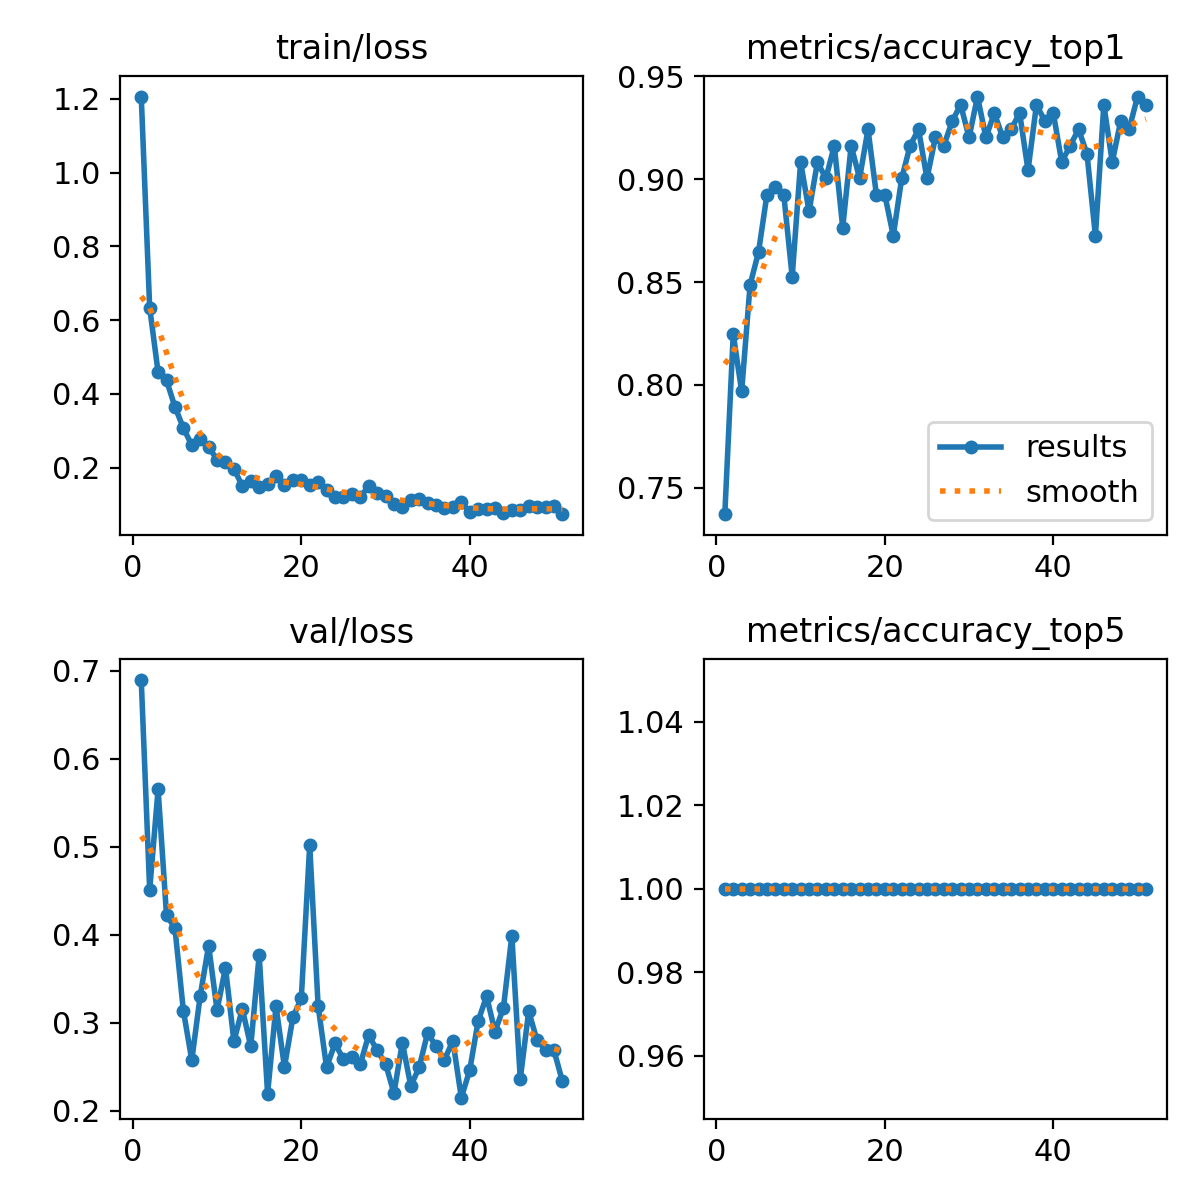

In [12]:
from IPython.display import Image as IPImage, display

results_png = save_dir / "results.png"
if results_png.exists():
    display(IPImage(str(results_png)))
else:
    print(f"results.png nu a fost găsit în {save_dir}")

---
## Copiere best.pt în locația corectă pentru aplicație

Aplicația FastAPI caută clasificatorul la:
`runs/classify/parks-cls-B2/weights/best.pt`

Dacă YOLOv8 a creat un director cu număr (ex: `parks-cls-B22`), celula de mai jos copiază automat.

---
## Analiza Curbe Antrenare


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

for run_name in ['parks-cls-B2', 'parks-cls-B23']:
    csv_path = REPO_ROOT / 'runs' / 'classify' / run_name / 'results.csv'
    if csv_path.exists(): break

df = pd.read_csv(csv_path); df.columns = df.columns.str.strip()
ep = df['epoch']
best_idx = df['metrics/accuracy_top1'].idxmax()
best_epoch = int(df.loc[best_idx, 'epoch'])
best_acc = float(df.loc[best_idx, 'metrics/accuracy_top1'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Curbe Antrenare B2 ({len(df)} epoci, early stop la patience=20)', fontsize=12)

axes[0].plot(ep, df['train/loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(ep, df['val/loss'],   label='Val',   color='tomato',    lw=2)
axes[0].axvline(best_epoch, color='green', ls='--', alpha=0.8, label=f'Best ep={best_epoch}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoca'); axes[0].legend()

axes[1].plot(ep, df['metrics/accuracy_top1'], color='mediumseagreen', lw=2)
axes[1].axvline(best_epoch, color='green', ls='--', alpha=0.8, label=f'Best={best_acc:.3f}')
axes[1].axhline(best_acc, color='gray', ls=':', alpha=0.7)
axes[1].set_title('Top-1 Accuracy (val)'); axes[1].set_xlabel('Epoca'); axes[1].legend()

if 'metrics/accuracy_top5' in df.columns:
    axes[2].plot(ep, df['metrics/accuracy_top5'], color='darkorange', lw=2)
axes[2].set_title('Top-5 Accuracy (val)'); axes[2].set_xlabel('Epoca')

plt.tight_layout()
out = REPO_ROOT / 'runs' / 'classify' / 'parks-cls-B2' / 'training_curves_B2.png'
plt.savefig(str(out), dpi=150, bbox_inches='tight')
plt.show()
print(f'Best epoch: {best_epoch} | Val Top-1: {best_acc:.4f}')
print(f'Early stop: {len(df)} epoci din 200 max (plateau detectat la patience=20)')

---
## Evaluare TEST set (metrica finala)


In [ ]:
# TEST set evaluation (metrica finala separata de val)
from ultralytics import YOLO
import json

BEST_PT = REPO_ROOT / 'runs' / 'classify' / 'parks-cls-B2' / 'weights' / 'best.pt'
assert BEST_PT.exists(), f'Ruleaza mai intai antrenarea! {BEST_PT}'

m_test = YOLO(str(BEST_PT))
test_r = m_test.val(
    data=DATA_DIR, split='test', imgsz=IMGSZ,
    batch=BATCH, device=DEVICE, workers=0, verbose=True,
)
rd = getattr(test_r, 'results_dict', {})
top1 = rd.get('metrics/accuracy_top1', 0)
top5 = rd.get('metrics/accuracy_top5', 0)
spd  = getattr(test_r, 'speed', {})

print('='*55)
print('  EVALUARE TEST SET B2 (metrica finala teza)')
print('='*55)
print(f'  Top-1 Accuracy : {top1:.4f}  ({top1*100:.2f}%)')
print(f'  Top-5 Accuracy : {top5:.4f}')
print(f'  Speed          : {spd.get("inference",0):.1f} ms/img')
print(f'  Val vs Test    : 94.02% vs {top1*100:.2f}% (delta normal)')
print('='*55)

# Salveaza results
out = REPO_ROOT / 'results' / 'classifier' / 'B2-test.json'
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps({'model':'B2','dataset':'trashnet_cls','split':'test',
    'n_images':257,'top1':round(top1,4),'top5':round(top5,4)}, indent=2), encoding='utf-8')
print(f'Salvat: {out}')

In [13]:
import shutil
from pathlib import Path
import glob

REPO_ROOT = Path("../..").resolve()
TARGET = REPO_ROOT / "runs" / "classify" / "parks-cls-B2" / "weights" / "best.pt"

# Găsește cel mai recent best.pt antrenat (parks-cls-B2 sau parks-cls-B2N)
candidates = sorted(
    glob.glob(str(REPO_ROOT / "runs" / "classify" / "parks-cls-B2*" / "weights" / "best.pt")),
    key=lambda p: Path(p).stat().st_mtime,
    reverse=True
)

if not candidates:
    print("[EROARE] Nu am găsit niciun best.pt! Rulează mai întâi celula de antrenare.")
else:
    src = Path(candidates[0])
    TARGET.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, TARGET)
    size_kb = TARGET.stat().st_size // 1024
    print(f"[OK] Copiat: {src.parent.parent.name}/weights/best.pt → {TARGET.parent.parent.name}/weights/best.pt")
    print(f"Dimensiune: {size_kb} KB")
    print(f"\nAplicatia va folosi: {TARGET}")
    print("Reporneste serverul FastAPI ca sa incarce noul clasificator.")

[OK] Copiat: parks-cls-B27/weights/best.pt → parks-cls-B2/weights/best.pt
Dimensiune: 2903 KB

Aplicatia va folosi: D:\TrashDetectionSystem\runs\classify\parks-cls-B2\weights\best.pt
Reporneste serverul FastAPI ca sa incarce noul clasificator.


---
## Experimente multiple B1, B2, B3

In [ ]:
import pandas as pd

# Tabel comparativ final B1 / B2 / B3
df_cmp = pd.DataFrame([
    {'Exp':'B1','Dataset':'parks_cls (crops proprii)','N_train':0,   'Val_Top1':None, 'Test_Top1':None, 'Note':'Dataset insuficient'},
    {'Exp':'B2','Dataset':'trashnet_cls (public)',    'N_train':2019,'Val_Top1':0.940,'Test_Top1':0.914,'Note':'SELECTAT productie'},
    {'Exp':'B3','Dataset':'mixed_cls (parks+TrashNet)','N_train':2649,'Val_Top1':0.913,'Test_Top1':0.913,'Note':'Similar B2'},
]).set_index('Exp')

print('=== Tabel comparativ B1/B2/B3 ===')
print(df_cmp.to_string())
print()
print('Model ales: B2 (TrashNet) — cel mai bun raport accuracy/diversitate')